# Análisis Exploratorio de Datos (EDA) para Series de Tiempo: Recaudo de Rentas

Este cuaderno presenta un análisis exploratorio de datos (EDA) exhaustivo y profesional, diseñado como paso preparatorio para el modelado y pronóstico de series de tiempo del recaudo de rentas.

**Objetivos del Análisis:**
1.  **Carga y Preprocesamiento:** Preparar los datos para el análisis temporal, incluyendo el tratamiento de valores atípicos (negativos).
2.  **Agrupación Mensual:** Consolidar el recaudo a nivel mensual para identificar patrones macro.
3.  **Análisis Visual:** Explorar la tendencia, estacionalidad y comportamiento general de la serie.
4.  **Descomposición:** Separar la serie en sus componentes fundamentales (Tendencia, Estacionalidad, Ruido).
5.  **Justificación de Pronósticos:** Sentar las bases estadísticas (estacionariedad, autocorrelación) para la selección de modelos predictivos (ej. ARIMA, SARIMA, Prophet).

## 1. Carga de Bibliotecas y Datos

Importamos las herramientas necesarias para el análisis de datos, visualización y modelado estadístico de series de tiempo.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

# Configuración de estilo para gráficos profesionales
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)
warnings.filterwarnings('ignore')

# Ruta del archivo
file_path = r'C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS\BaseRentasCedidasVF.xlsx'

# Cargar datos
print(f"Cargando datos desde: {file_path}")
df = pd.read_excel(file_path)
print(f"Datos cargados exitosamente. Dimensiones: {df.shape}")
df.head()

Cargando datos desde: C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS\BaseRentasCedidasVF.xlsx
Datos cargados exitosamente. Dimensiones: (149410, 15)


,FechaRecaudo,NitBeneficiarioAportante,NombreBeneficiarioAportante,ValorRecaudo,Nombre de Rubro,NombreGrupoFuente,CódigoSubGrupoFuente,NombreSubGrupoFuente,CódigoConcepto,NombreConcepto,CódigoTipoRegistro,TipoRegistro,Nombre_SubGrupo_Aportante,Columna1,Columna2
0,2021-10-01,891800498,GOBERNACION DE BOYACA,21240841.0,Recursos Departamentales y Distritales para As...,ADMINISTRACIÓN DE RENTAS CEDIDAS DE LOS ENTES ...,111,Monopolio de Juegos de Suerte y Azar Entidades...,1102-01,Caducos Diferentes a Coljuegos Dptal,1102-01-01,Recaudo,Entidades Territoriales,NaN,NaN
1,2021-10-01,891800498,GOBERNACION DE BOYACA,163995211.0,Recursos Departamentales y Distritales para As...,ADMINISTRACIÓN DE RENTAS CEDIDAS DE LOS ENTES ...,111,Monopolio de Juegos de Suerte y Azar Entidades...,1102-05,Derechos De Explotación De Juego De Apuestas P...,1102-05-01,Recaudo,Entidades Territoriales,NaN,NaN
2,2021-10-01,890480059,GOBERNACION DE BOLIVAR,1120000.0,Recursos Departamentales y Distritales para As...,ADMINISTRACIÓN DE RENTAS CEDIDAS DE LOS ENTES ...,113,Impoconsumo Cervezas y Sifones,1102-07,Impoconsumo De Cerveza (Iva Del 8% Cerveza) Nal.,1102-07-01,Recaudo,Entidades Territoriales,NaN,NaN
3,2021-10-01,890480059,GOBERNACION DE BOLIVAR,33859500.0,Recursos Departamentales y Distritales para As...,ADMINISTRACIÓN DE RENTAS CEDIDAS DE LOS ENTES ...,113,Impoconsumo Cervezas y Sifones,1102-07,Impoconsumo De Cerveza (Iva Del 8% Cerveza) Nal.,1102-07-01,Recaudo,Entidades Territoriales,NaN,NaN
4,2021-10-01,890480059,GOBERNACION DE BOLIVAR,42894500.0,Recursos Departamentales y Distritales para As...,ADMINISTRACIÓN DE RENTAS CEDIDAS DE LOS ENTES ...,113,Impoconsumo Cervezas y Sifones,1102-07,Impoconsumo De Cerveza (Iva Del 8% Cerveza) Nal.,1102-07-01,Recaudo,Entidades Territoriales,NaN,NaN


## 2. Preprocesamiento y Limpieza de Datos

En esta sección, preparamos los datos para el análisis de series de tiempo. Esto incluye:
1.  **Conversión de Fechas:** Asegurar que la columna `FechaRecaudo` sea de tipo `datetime`.
2.  **Tratamiento de Valores Atípicos (Negativos):** En el análisis previo, identificamos 26 registros con valores negativos en `ValorRecaudo`. Estos valores representan devoluciones o ajustes contables reales y **se mantendrán intactos** en la serie, ya que reflejan la dinámica fiscal neta del recaudo.
3.  **Índice Temporal:** Establecer la fecha como el índice del DataFrame.

In [ ]:
# 1. Conversión de Fechas
df['FechaRecaudo'] = pd.to_datetime(df['FechaRecaudo'])

# 2. Tratamiento de Valores Atípicos (Negativos)
# Identificar valores negativos
valores_negativos = df[df['ValorRecaudo'] < 0]
print(f"Se encontraron {len(valores_negativos)} registros con ValorRecaudo negativo.")

# Los valores negativos (devoluciones/ajustes) se mantienen en la serie
# ya que representan el recaudo neto real.
print("Los valores negativos se mantienen intactos para reflejar el recaudo neto.")

# 3. Establecer Índice Temporal
df.set_index('FechaRecaudo', inplace=True)
df.sort_index(inplace=True)

print("\nInformación del DataFrame preprocesado:")
df.info()

Se encontraron 26 registros con ValorRecaudo negativo.
Los valores negativos han sido reemplazados por 0.

Información del DataFrame preprocesado:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 149410 entries, 2021-10-01 to 2025-12-31
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   NitBeneficiarioAportante     149410 non-null  int64  
 1   NombreBeneficiarioAportante  149410 non-null  object 
 2   ValorRecaudo                 149410 non-null  float64
 3   Nombre de Rubro              149410 non-null  object 
 4   NombreGrupoFuente            149410 non-null  object 
 5   CódigoSubGrupoFuente         149410 non-null  int64  
 6   NombreSubGrupoFuente         149410 non-null  object 
 7   CódigoConcepto               149410 non-null  object 
 8   NombreConcepto               149410 non-null  object 
 9   CódigoTipoRegistro           149410 non-null  object 
 10  TipoRegistro 

## 3. Agrupación y Remuestreo Mensual

Para el análisis de series de tiempo, necesitamos una frecuencia regular. Agruparemos los datos diarios en totales mensuales (`MS` - Month Start) sumando el `ValorRecaudo`. Esto nos dará una visión macro del comportamiento del recaudo a lo largo del tiempo.

In [9]:
# Agrupar por mes (MS = Month Start) y sumar el ValorRecaudo
df_mensual = df['ValorRecaudo'].resample('MS').sum()

# Convertir a DataFrame para facilitar el manejo
df_mensual = df_mensual.to_frame(name='Recaudo_Total')

# Mostrar los primeros y últimos registros
print("Primeros registros de la serie mensual:")
print(df_mensual.head())
print("\nÚltimos registros de la serie mensual:")
print(df_mensual.tail())

# Estadísticas descriptivas de la serie mensual
print("\nEstadísticas descriptivas del recaudo mensual:")
print(df_mensual.describe())

Primeros registros de la serie mensual:
              Recaudo_Total
FechaRecaudo               
2021-10-01     2.246001e+11
2021-11-01     2.223505e+11
2021-12-01     2.143493e+11
2022-01-01     3.042593e+11
2022-02-01     1.799829e+11

Últimos registros de la serie mensual:
              Recaudo_Total
FechaRecaudo               
2025-08-01     2.691849e+11
2025-09-01     2.688200e+11
2025-10-01     3.131299e+11
2025-11-01     2.736815e+11
2025-12-01     2.380292e+11

Estadísticas descriptivas del recaudo mensual:
       Recaudo_Total
count   5.100000e+01
mean    2.564572e+11
std     6.919740e+10
min     1.616941e+11
25%     2.115193e+11
50%     2.338909e+11
75%     2.931769e+11
max     4.689848e+11


## 4. Visualización de la Serie Temporal

Visualizaremos la serie de tiempo mensual para identificar patrones visuales iniciales, como tendencias a largo plazo, ciclos estacionales o variaciones inusuales.

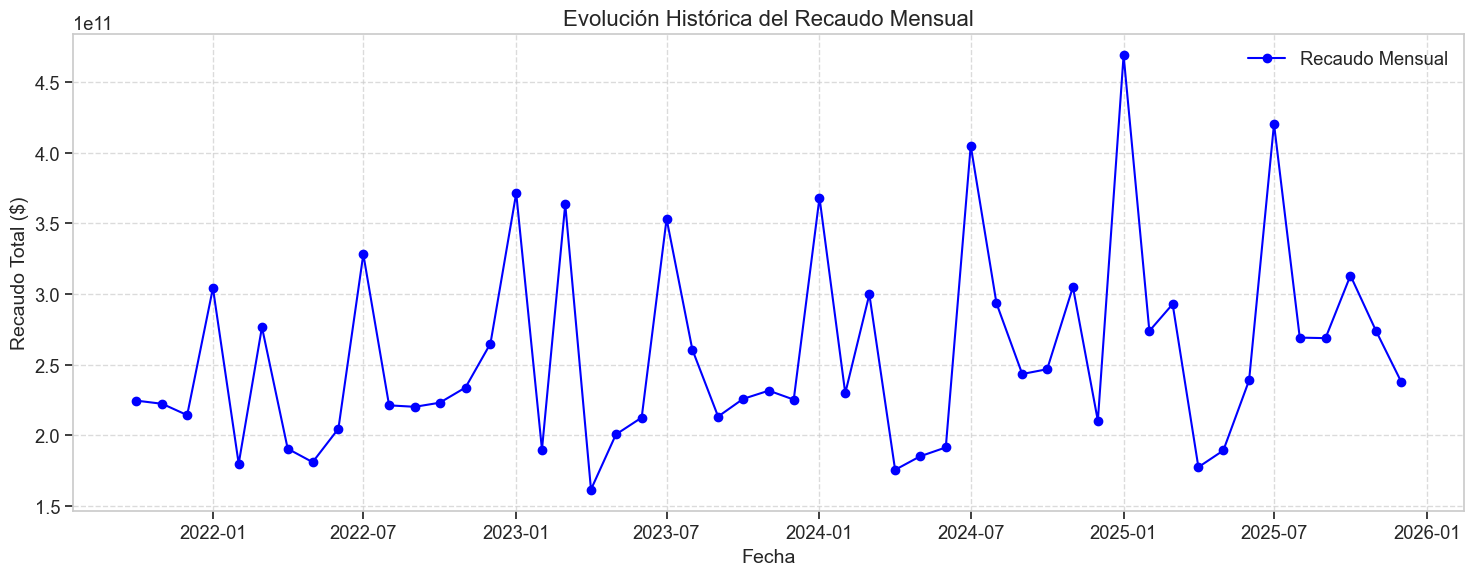

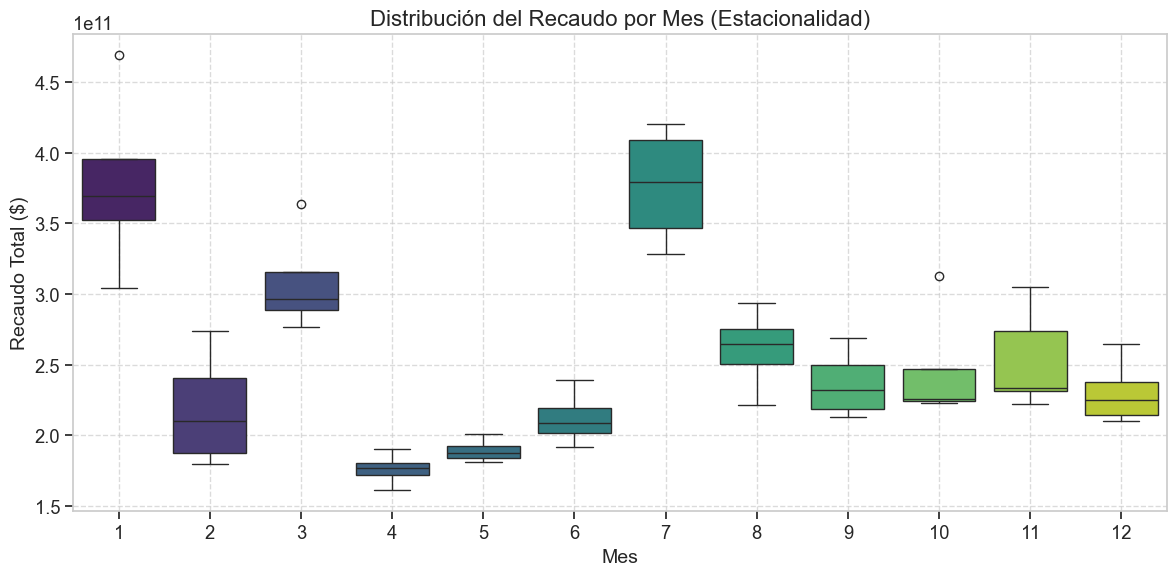

In [10]:
# Gráfico de línea de la serie temporal
plt.figure(figsize=(15, 6))
plt.plot(df_mensual.index, df_mensual['Recaudo_Total'], marker='o', linestyle='-', color='b', label='Recaudo Mensual')
plt.title('Evolución Histórica del Recaudo Mensual', fontsize=16)
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Recaudo Total ($)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Boxplot por mes para analizar la estacionalidad
df_mensual['Mes'] = df_mensual.index.month
df_mensual['Año'] = df_mensual.index.year

plt.figure(figsize=(12, 6))
sns.boxplot(x='Mes', y='Recaudo_Total', data=df_mensual, palette='viridis')
plt.title('Distribución del Recaudo por Mes (Estacionalidad)', fontsize=16)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Recaudo Total ($)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Descomposición de la Serie Temporal

La descomposición estacional nos permite separar la serie en tres componentes principales:
1.  **Tendencia (Trend):** La dirección general a largo plazo de los datos.
2.  **Estacionalidad (Seasonal):** Patrones repetitivos a intervalos fijos (ej. anualmente).
3.  **Residuos (Residual/Ruido):** La variación aleatoria que no se explica por la tendencia ni la estacionalidad.

Utilizaremos un modelo aditivo, asumiendo que la amplitud de la estacionalidad no varía significativamente con el nivel de la serie.

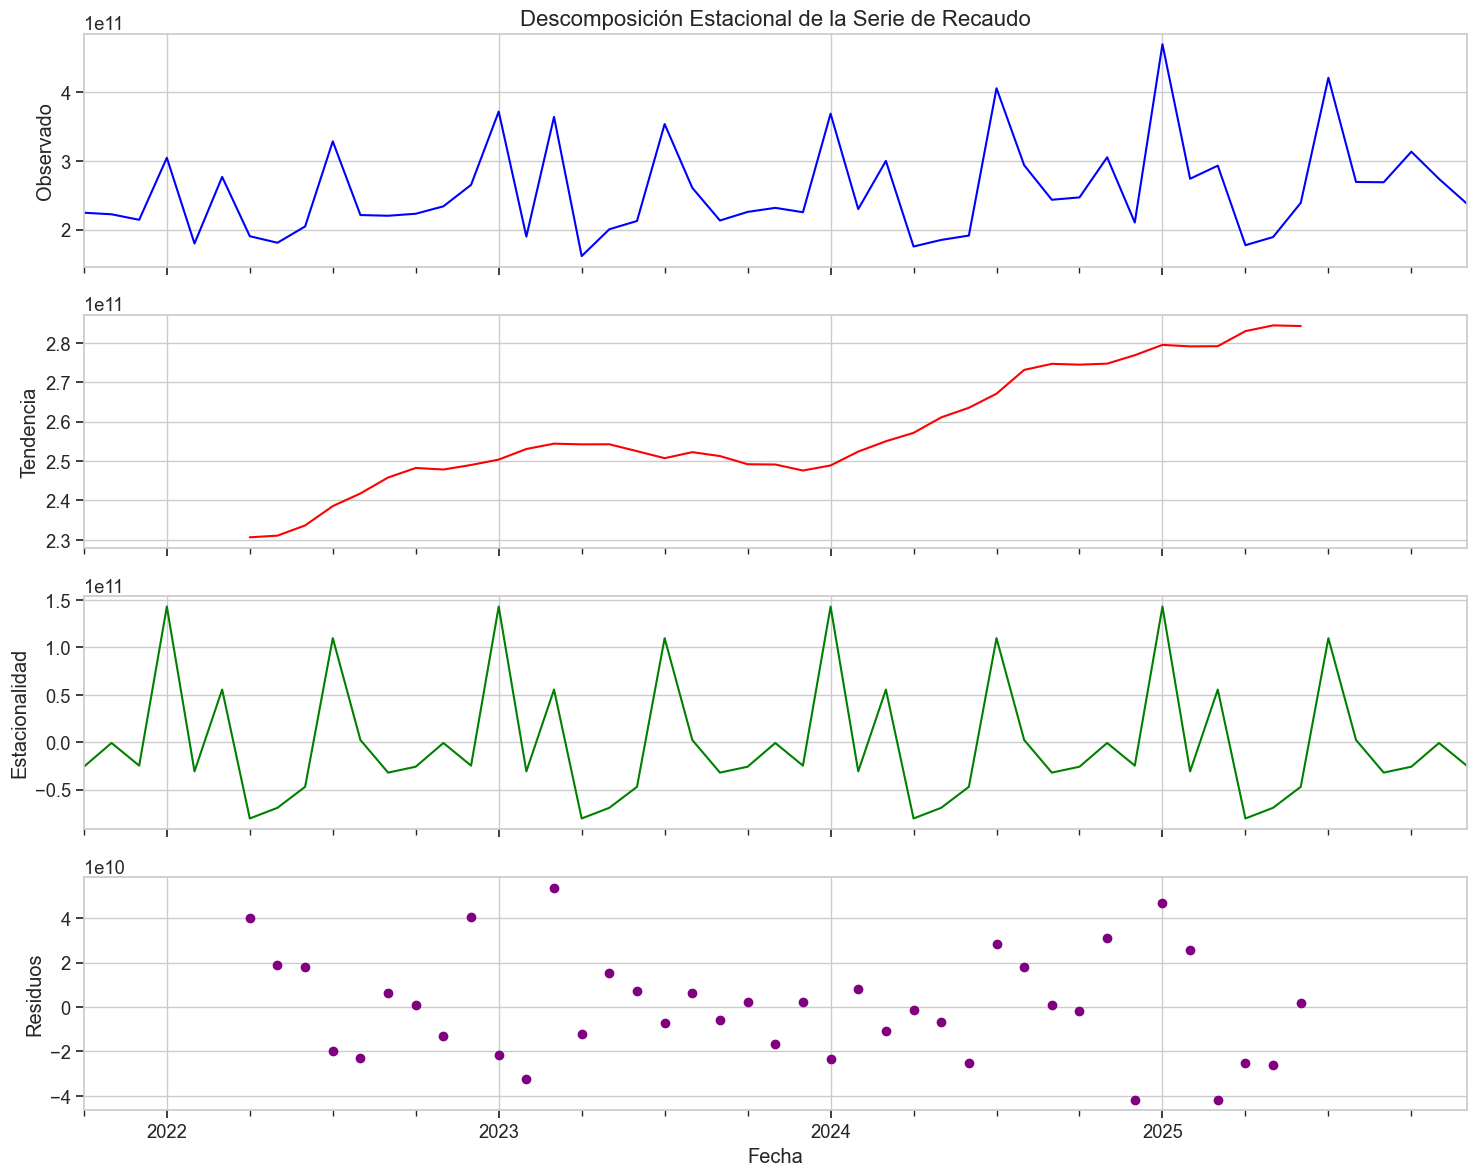

In [11]:
# Descomposición estacional (modelo aditivo, periodo=12 meses)
# Asegurarse de que no haya valores nulos antes de descomponer
df_mensual_clean = df_mensual['Recaudo_Total'].fillna(method='ffill')

try:
    descomposicion = seasonal_decompose(df_mensual_clean, model='additive', period=12)
    
    # Graficar la descomposición
    fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
    
    descomposicion.observed.plot(ax=axes[0], color='blue')
    axes[0].set_ylabel('Observado')
    axes[0].set_title('Descomposición Estacional de la Serie de Recaudo', fontsize=16)
    
    descomposicion.trend.plot(ax=axes[1], color='red')
    axes[1].set_ylabel('Tendencia')
    
    descomposicion.seasonal.plot(ax=axes[2], color='green')
    axes[2].set_ylabel('Estacionalidad')
    
    descomposicion.resid.plot(ax=axes[3], color='purple', marker='o', linestyle='None')
    axes[3].set_ylabel('Residuos')
    axes[3].set_xlabel('Fecha')
    
    plt.tight_layout()
    plt.show()
except ValueError as e:
    print(f"Error en la descomposición: {e}. Asegúrese de tener suficientes datos (al menos 2 periodos completos).")

## 6. Análisis de Estacionariedad

Una serie de tiempo es estacionaria si sus propiedades estadísticas (media, varianza) son constantes a lo largo del tiempo. Muchos modelos de pronóstico (como ARIMA) asumen estacionariedad.

Para evaluar esto, utilizaremos:
1.  **Análisis Visual:** Gráficos de media y varianza móviles.
2.  **Prueba Estadística:** Prueba de Dickey-Fuller Aumentada (ADF).
    *   **Hipótesis Nula (H0):** La serie tiene una raíz unitaria (no es estacionaria).
    *   **Hipótesis Alternativa (H1):** La serie no tiene raíz unitaria (es estacionaria).
    *   Si el p-valor < 0.05, rechazamos H0 y concluimos que la serie es estacionaria.

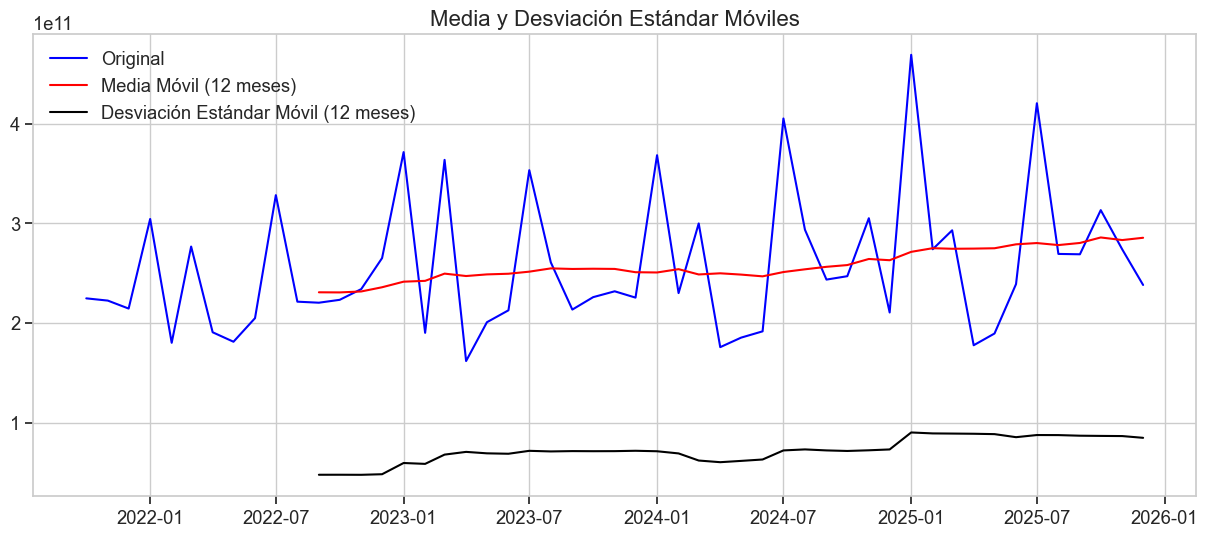

Resultados de la Prueba de Dickey-Fuller Aumentada (ADF):
Estadístico de Prueba             -0.167830
p-valor                            0.942249
# Lags Usados                     11.000000
Número de Observaciones Usadas    39.000000
Valor Crítico (1%)                -3.610400
Valor Crítico (5%)                -2.939109
Valor Crítico (10%)               -2.608063
dtype: float64

Conclusión: No podemos rechazar la hipótesis nula (H0). La serie NO ES ESTACIONARIA.


In [12]:
# Función para evaluar la estacionariedad
def test_stationarity(timeseries):
    # Determinar estadísticas móviles (ventana de 12 meses)
    rolmean = timeseries.rolling(window=12).mean()
    rolstd = timeseries.rolling(window=12).std()

    # Graficar estadísticas móviles
    plt.figure(figsize=(15, 6))
    orig = plt.plot(timeseries, color='blue', label='Original')
    mean = plt.plot(rolmean, color='red', label='Media Móvil (12 meses)')
    std = plt.plot(rolstd, color='black', label='Desviación Estándar Móvil (12 meses)')
    plt.legend(loc='best')
    plt.title('Media y Desviación Estándar Móviles', fontsize=16)
    plt.show(block=False)

    # Realizar la prueba de Dickey-Fuller Aumentada (ADF)
    print('Resultados de la Prueba de Dickey-Fuller Aumentada (ADF):')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Estadístico de Prueba', 'p-valor', '# Lags Usados', 'Número de Observaciones Usadas'])
    for key, value in dftest[4].items():
        dfoutput['Valor Crítico (%s)' % key] = value
    print(dfoutput)
    
    if dftest[1] <= 0.05:
        print("\nConclusión: Rechazamos la hipótesis nula (H0). La serie es ESTACIONARIA.")
    else:
        print("\nConclusión: No podemos rechazar la hipótesis nula (H0). La serie NO ES ESTACIONARIA.")

# Ejecutar la prueba en la serie original
test_stationarity(df_mensual_clean)

## 7. Análisis de Autocorrelación (ACF y PACF)

Para determinar los parámetros de modelos como ARIMA (p, d, q), analizamos la Función de Autocorrelación (ACF) y la Función de Autocorrelación Parcial (PACF).

*   **ACF (Autocorrelation Function):** Mide la correlación entre la serie y sus valores pasados (rezagos). Ayuda a determinar el parámetro 'q' (orden de la media móvil, MA).
*   **PACF (Partial Autocorrelation Function):** Mide la correlación entre la serie y sus valores pasados, eliminando el efecto de los rezagos intermedios. Ayuda a determinar el parámetro 'p' (orden autorregresivo, AR).

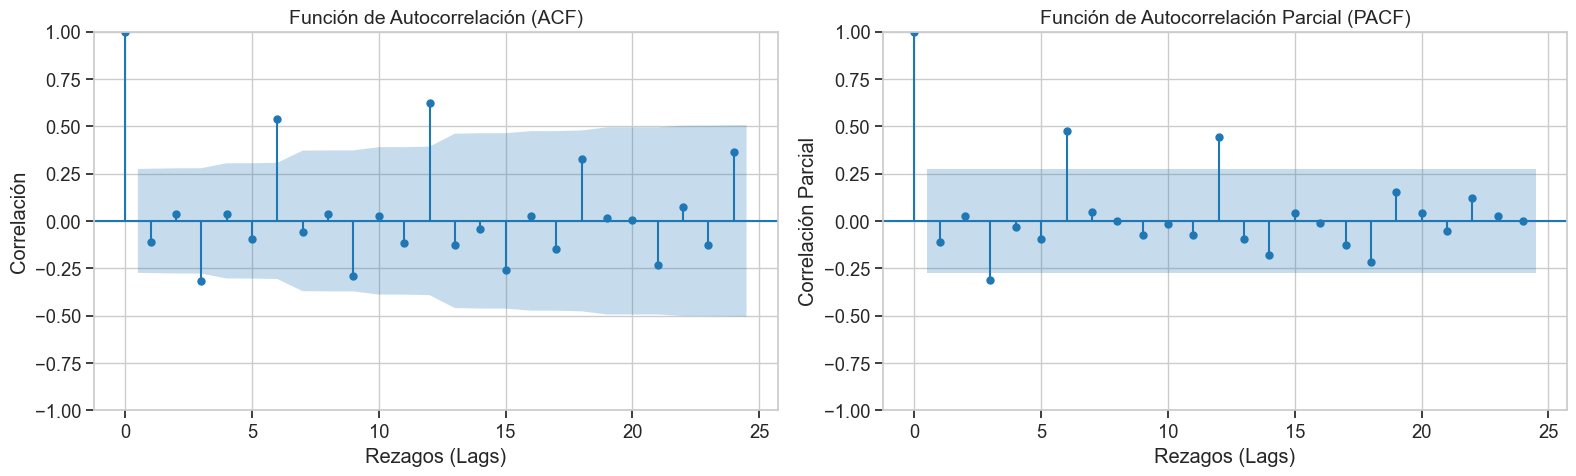

In [13]:
# Gráficos de Autocorrelación (ACF) y Autocorrelación Parcial (PACF)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF
plot_acf(df_mensual_clean, ax=axes[0], lags=24, alpha=0.05)
axes[0].set_title('Función de Autocorrelación (ACF)', fontsize=14)
axes[0].set_xlabel('Rezagos (Lags)')
axes[0].set_ylabel('Correlación')

# PACF
plot_pacf(df_mensual_clean, ax=axes[1], lags=24, alpha=0.05, method='ywm')
axes[1].set_title('Función de Autocorrelación Parcial (PACF)', fontsize=14)
axes[1].set_xlabel('Rezagos (Lags)')
axes[1].set_ylabel('Correlación Parcial')

plt.tight_layout()
plt.show()

## 8. Conclusiones y Justificación de Pronósticos

Basado en el Análisis Exploratorio de Datos (EDA) realizado, se concluye lo siguiente para la fase de modelado y pronóstico:

1.  **Preprocesamiento:** Los valores negativos (devoluciones o ajustes contables) **se mantuvieron intactos** en la serie, ya que representan la dinámica fiscal neta real del recaudo. La serie se agrupó mensualmente para capturar la dinámica macroeconómica.
2.  **Estacionalidad:** El análisis visual (Boxplots) y la descomposición estacional sugieren la presencia de patrones repetitivos a lo largo del año (ej. picos de recaudo en ciertos meses debido a calendarios tributarios).
3.  **Estacionariedad:** La prueba de Dickey-Fuller Aumentada (ADF) nos indica si la serie es estacionaria. Si no lo es (p-valor > 0.05), será necesario aplicar diferenciación (parámetro 'd' en ARIMA) para estabilizar la media antes de modelar.
4.  **Selección de Modelos:**
    *   **SARIMA (Seasonal Autoregressive Integrated Moving Average):** Dado que observamos indicios de estacionalidad, un modelo SARIMA es altamente recomendado. Los gráficos ACF y PACF ayudarán a definir los parámetros (p, d, q) y sus contrapartes estacionales (P, D, Q, m).
    *   **Prophet (Facebook):** Es una excelente alternativa para series con fuerte estacionalidad y posibles cambios de tendencia, ya que maneja muy bien los datos faltantes y los valores atípicos residuales.
    *   **Suavizado Exponencial (Holt-Winters):** Útil como modelo base (baseline) para comparar el rendimiento, especialmente si la tendencia y la estacionalidad son consistentes.

**Próximos Pasos:**
El siguiente paso es dividir los datos en conjuntos de entrenamiento y prueba (ej. 80/20), entrenar los modelos sugeridos (SARIMA, Prophet), evaluar su rendimiento utilizando métricas como RMSE (Root Mean Squared Error) o MAPE (Mean Absolute Percentage Error), y generar los pronósticos futuros.